In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/2017_jun_final - 2017_jun_final.csv")

In [2]:
df.head()

,N,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,...,False,Intermediate (середній),"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,...,False,Pre-intermediate (нище середнього),"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,...,False,Intermediate (середній),"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


In [3]:
df.shape

(8704, 25)

In [4]:
df.dtypes

N                                     int64
Посада                                  str
Мова програмування                      str
Спеціалізація                           str
Загальний досвід роботи                 str
Досвід роботи на поточному місці        str
Зарплата на місяць                    int64
Зміна зарплати за 12 місяців          int64
Місто                                   str
Розмір компанії                         str
Тип компанії                            str
Стать                                   str
Вік                                   int64
Освіта                                  str
Університет                             str
Ще студент                             bool
Рівень англійської                      str
Предметна область                       str
Дата заповнення                         str
User.Agent                              str
exp                                 float64
current_job_exp                     float64
salary                          

In [5]:
nan_part = df.isnull().sum() / len(df)
nan_part

N                                   0.000000
Посада                              0.000000
Мова програмування                  0.442325
Спеціалізація                       0.829389
Загальний досвід роботи             0.000000
Досвід роботи на поточному місці    0.000000
Зарплата на місяць                  0.000000
Зміна зарплати за 12 місяців        0.000000
Місто                               0.000000
Розмір компанії                     0.000000
Тип компанії                        0.000000
Стать                               0.000000
Вік                                 0.000000
Освіта                              0.000000
Університет                         0.041131
Ще студент                          0.000000
Рівень англійської                  0.000000
Предметна область                   0.025620
Дата заповнення                     0.000000
User.Agent                          0.000000
exp                                 0.000000
current_job_exp                     0.000000
salary    

In [6]:
df = df.loc[:, ~df.isnull().any() | (df.columns == "Мова програмування")]

In [7]:
nan_part = df.isnull().sum() / len(df)
nan_part

N                                   0.000000
Посада                              0.000000
Мова програмування                  0.442325
Загальний досвід роботи             0.000000
Досвід роботи на поточному місці    0.000000
Зарплата на місяць                  0.000000
Зміна зарплати за 12 місяців        0.000000
Місто                               0.000000
Розмір компанії                     0.000000
Тип компанії                        0.000000
Стать                               0.000000
Вік                                 0.000000
Освіта                              0.000000
Ще студент                          0.000000
Рівень англійської                  0.000000
Дата заповнення                     0.000000
User.Agent                          0.000000
exp                                 0.000000
current_job_exp                     0.000000
salary                              0.000000
dtype: float64

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(4854, 20)

In [10]:
python_data = df[df["Мова програмування"] == "Python"]

In [11]:
python_data.shape

(207, 20)

In [12]:
df_grouped = python_data.groupby(["Посада"]).agg(min=("Зарплата на місяць", "min"), max=("Зарплата на місяць", "max")
).reset_index()
df_grouped

,Посада,min,max
0,Junior Software Engineer,100,1250
1,Senior Software Engineer,1300,9200
2,Software Engineer,500,5400
3,System Architect,3000,5000
4,Technical Lead,1425,6200


In [13]:
def fill_avg_salary(series):
    return series.mean()

In [14]:
df_grouped["avg"] = df_grouped[["min", "max"]].apply(fill_avg_salary, axis=1)

In [15]:
df_grouped["avg"].describe()

count       5.000000
mean     3337.500000
std      1700.091909
min       675.000000
25%      2950.000000
50%      3812.500000
75%      4000.000000
max      5250.000000
Name: avg, dtype: float64

In [16]:
df_grouped.to_csv("min_max_avg_salary_python_2017.csv", index=False)

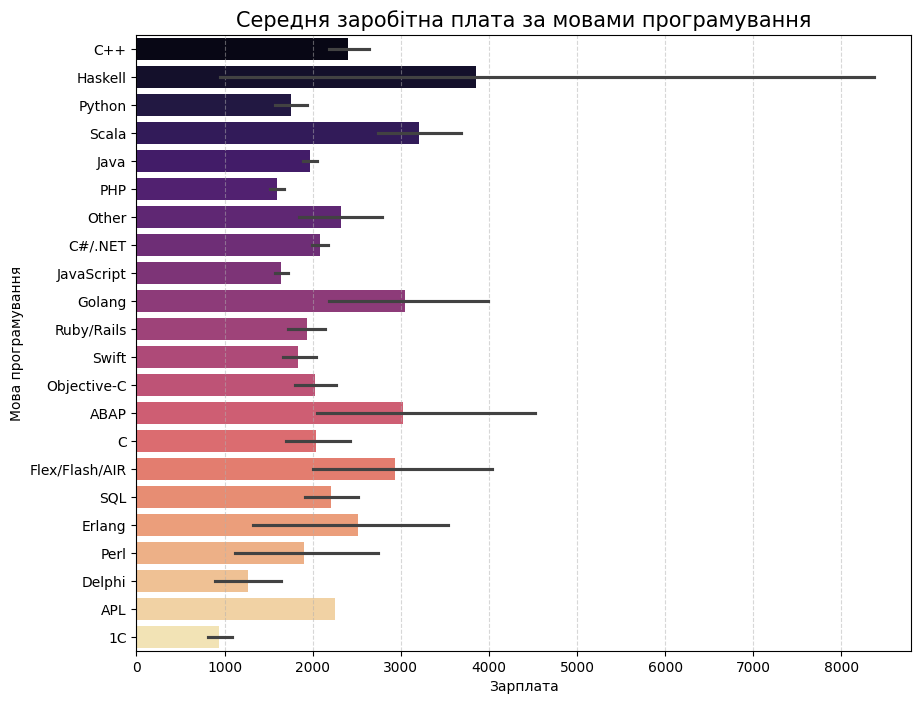

In [20]:
plt.figure(figsize=(10, 8))

sns.barplot(x='Зарплата на місяць', y='Мова програмування', data=df.sort_values('Зарплата на місяць', ascending=False), 
            palette='magma', hue='Мова програмування', legend=False)

plt.title('Середня заробітна плата за мовами програмування', fontsize=15)
plt.xlabel('Зарплата')
plt.ylabel('Мова програмування')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

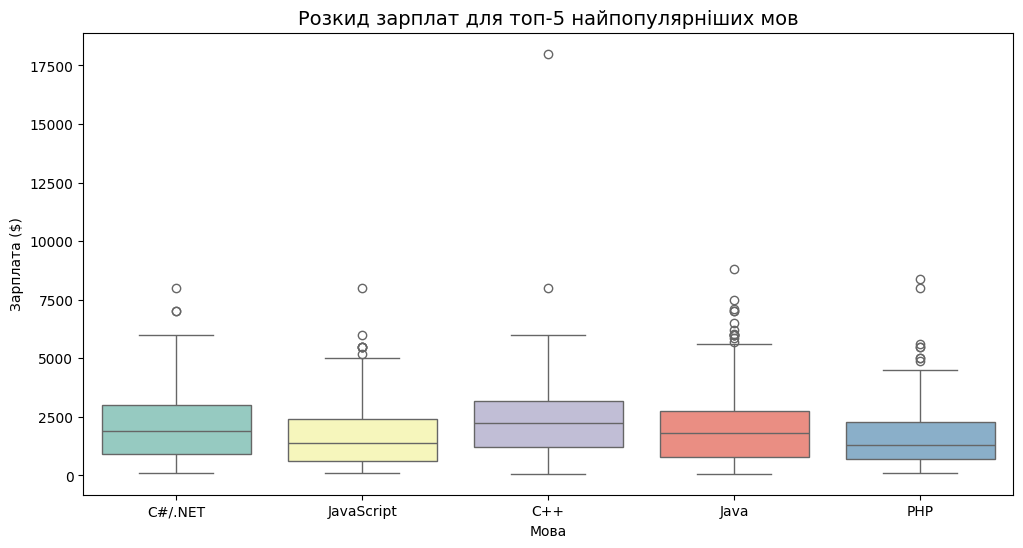

In [28]:
plt.figure(figsize=(12, 6))

top_languages = df['Мова програмування'].value_counts().head(5).index
df_top = df[df['Мова програмування'].isin(top_languages)]

sns.boxplot(x='Мова програмування', y='Зарплата на місяць', data=df_top, palette='Set3', hue='Мова програмування', legend=False)

plt.title('Розкид зарплат для топ-5 найпопулярніших мов', fontsize=14)
plt.xlabel('Мова')
plt.ylabel('Зарплата ($)')
plt.show()

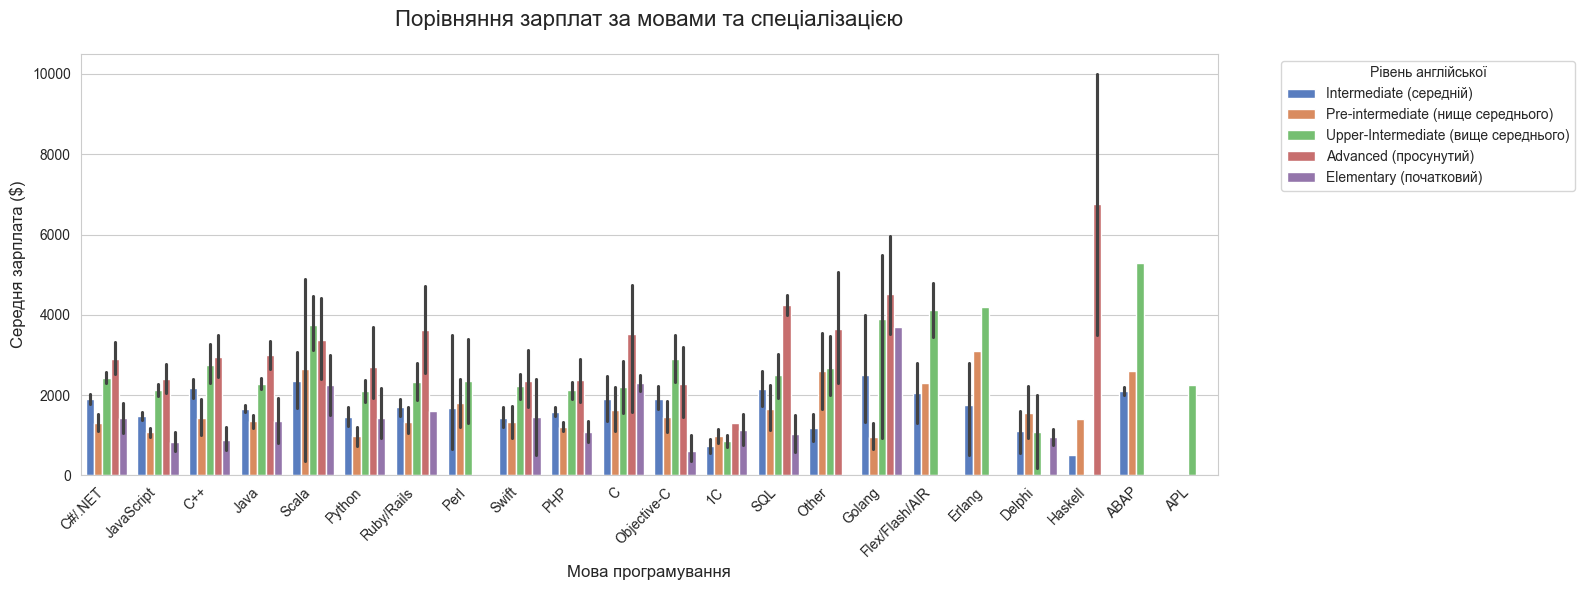

In [39]:
sns.set_style("whitegrid")

plt.figure(figsize=(16, 6))

sns.barplot(x='Мова програмування', y='Зарплата на місяць', hue='Рівень англійської', data=df, palette='muted')

plt.xticks(rotation=45, ha='right')

plt.title('Порівняння зарплат за мовами та спеціалізацією', fontsize=16, pad=20)
plt.xlabel('Мова програмування', fontsize=12)
plt.ylabel('Середня зарплата ($)', fontsize=12)
plt.legend(title='Рівень англійської', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()